In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import random
import warnings
import gc

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
class DatasetHandler:
    def __init__(self):
        self.X = None
        self.y = None
        self.scaler = StandardScaler()
        self.data = {}

    def load(self, n_samples=5000, n_features=100):
        print(f"Генерация датасета: {n_samples} объектов, {n_features} признаков...")
        self.X, self.y = make_classification(
            n_samples=n_samples, n_features=n_features,
            n_informative=40, n_redundant=10, n_clusters_per_class=2,
            random_state=SEED
        )
        self.X = self.X.astype(np.float32)
        self.y = self.y.astype(np.int32)
        print(f"Датасет создан. Shape X: {self.X.shape}, y: {self.y.shape}")

    def preprocess_and_split(self, test_size=0.15, val_size=0.15):
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=SEED, stratify=self.y)
        
        val_ratio = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_ratio, random_state=SEED, stratify=y_train_val)

        self.scaler.fit(X_train)
        self.data['X_train'] = self.scaler.transform(X_train)
        self.data['y_train'] = y_train
        self.data['X_val'] = self.scaler.transform(X_val)
        self.data['y_val'] = y_val
        self.data['X_test'] = self.scaler.transform(X_test)
        self.data['y_test'] = y_test
        print("Данные предобработаны и разделены.")
        return self.data

In [3]:
ACTIVATIONS = ['relu', 'tanh', 'sigmoid']

class Individual:
    def __init__(self, hidden_layers=None, neurons_per_layer=None, 
                 activation_type=None, reg_coeff=None):
        self.hidden_layers = hidden_layers if hidden_layers is not None else np.random.randint(1, 5)
        self.neurons_per_layer = neurons_per_layer if neurons_per_layer is not None \
            else [int(x) for x in np.random.randint(8, 64, self.hidden_layers)]
        self.activation_type = activation_type if activation_type is not None \
            else [random.choice(ACTIVATIONS) for _ in range(self.hidden_layers)]
        self.reg_coeff = reg_coeff if reg_coeff is not None else np.random.choice([0.0, 0.001, 0.01])
        self.fitness = None
        self.model = None

    def decode(self, input_shape):
        model = keras.Sequential()
        model.add(layers.Input(shape=(input_shape,)))
        for i in range(self.hidden_layers):
            reg = regularizers.l2(self.reg_coeff) if self.reg_coeff > 0 else None
            model.add(layers.Dense(self.neurons_per_layer[i],
                                   activation=self.activation_type[i],
                                   kernel_regularizer=reg))
        model.add(layers.Dense(1, activation='sigmoid'))
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model

    def count_params(self, input_dim):
        params = input_dim * self.neurons_per_layer[0] + self.neurons_per_layer[0]
        for i in range(1, self.hidden_layers):
            params += self.neurons_per_layer[i-1] * self.neurons_per_layer[i] + self.neurons_per_layer[i]
        params += self.neurons_per_layer[-1] * 1 + 1
        return params

    def mutate(self, rate=0.3):
        if random.random() < rate:
            if self.hidden_layers > 1 and random.random() < 0.5:
                idx = random.randint(0, self.hidden_layers - 1)
                self.neurons_per_layer.pop(idx)
                self.activation_type.pop(idx)
                self.hidden_layers -= 1
            elif self.hidden_layers < 5:
                self.neurons_per_layer.append(np.random.randint(8, 64))
                self.activation_type.append(random.choice(ACTIVATIONS))
                self.hidden_layers += 1

        for i in range(len(self.neurons_per_layer)):
            if random.random() < rate:
                self.neurons_per_layer[i] = max(8, self.neurons_per_layer[i] + np.random.randint(-8, 8))

        for i in range(len(self.activation_type)):
            if random.random() < rate:
                self.activation_type[i] = random.choice(ACTIVATIONS)

    def __str__(self):
        return (f"Layers: {self.hidden_layers}, "
                f"Neurons: {self.neurons_per_layer}, "
                f"Acts: {self.activation_type}, "
                f"Reg: {self.reg_coeff}")

In [4]:
class FitnessEvaluator:
    def __init__(self, data, max_epochs=15, patience=3, penalty_weight=0.05):
        self.data = data
        self.max_epochs = max_epochs
        self.patience = patience
        self.penalty_weight = penalty_weight

    def evaluate(self, individual):
        model = individual.decode(self.data['X_train'].shape[1])
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=self.patience, 
                                           restore_best_weights=True, verbose=0)
        history = model.fit(self.data['X_train'], self.data['y_train'],
                            validation_data=(self.data['X_val'], self.data['y_val']),
                            epochs=self.max_epochs, batch_size=256, callbacks=[es], verbose=0)
        
        val_acc = np.max(history.history['val_accuracy'])
        param_count = individual.count_params(self.data['X_train'].shape[1])

        penalty = self.penalty_weight * (individual.hidden_layers + np.log10(param_count + 1) * 0.1)
        individual.fitness = val_acc - penalty
        individual.model = model
        gc.collect()
        return individual.fitness

In [5]:
class EvolutionaryOptimizer:
    def __init__(self, pop_size, evaluator, generations, mutation_rate, elitism_count):
        self.pop_size = pop_size
        self.evaluator = evaluator
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.elitism_count = elitism_count
        self.population = [Individual() for _ in range(pop_size)]
        self.history = {'best': [], 'avg': []}

    def run(self):
        print("Оценка начальной популяции...")
        self._evaluate_population()
        self._log()

        for gen in range(1, self.generations):
            self.population.sort(key=lambda x: x.fitness, reverse=True)
            elites = self.population[:self.elitism_count]

            new_generation = list(elites)
            while len(new_generation) < self.pop_size:
                parent = self._tournament_selection(k=3)
                child = self._create_child(parent)
                child.mutate(self.mutation_rate)
                new_generation.append(child)

            self.population = new_generation[:self.pop_size]
            self._evaluate_population()
            self._log()
            best = self.population[0]
            print(f"Поколение {gen}/{self.generations} | Best Fitness: {best.fitness:.4f} | Params: {best.count_params(100)}")

        return self.get_best()

    def _evaluate_population(self):
        for ind in self.population:
            self.evaluator.evaluate(ind)

    def _tournament_selection(self, k=3):
        contenders = random.sample(self.population, k)
        return max(contenders, key=lambda x: x.fitness)

    def _create_child(self, parent):
        return Individual(
            hidden_layers=parent.hidden_layers,
            neurons_per_layer=parent.neurons_per_layer.copy(),
            activation_type=parent.activation_type.copy(),
            reg_coeff=parent.reg_coeff
        )

    def _log(self):
        self.history['best'].append(self.population[0].fitness)
        self.history['avg'].append(np.mean([ind.fitness for ind in self.population]))

    def get_best(self):
        return self.population[0]

In [6]:
class Visualizer:
    def __init__(self, history, best_individual, y_true, y_pred):
        self.history = history
        self.best_individual = best_individual
        self.y_true = y_true
        self.y_pred = y_pred

    def plot_learning_curve(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.history['best'], label='Best Fitness', linewidth=2, marker='o')
        plt.plot(self.history['avg'], label='Average Fitness', linestyle='--', marker='s')
        plt.xlabel('Generation')
        plt.ylabel('Fitness (Accuracy - Penalty)')
        plt.title('Сходимость эволюционного алгоритма')
        plt.legend()
        plt.grid(True)
        plt.show()

    def draw_best_network(self):
        fig, ax = plt.subplots(figsize=(8, 4))
        layers_desc = [f"Input\n(100)"]
        for i, n in enumerate(self.best_individual.neurons_per_layer):
            layers_desc.append(f"Dense {i+1}\n({n}, {self.best_individual.activation_type[i]})")
        layers_desc.append(f"Output\n(1, sigmoid)")

        y_pos = np.arange(len(layers_desc))
        ax.barh(y_pos, np.ones_like(y_pos), align='center', height=0.5, color='lightcoral')
        for i, desc in enumerate(layers_desc):
            ax.text(0.5, i, desc, ha='center', va='center', fontsize=11, fontweight='bold')
        ax.set_xlim(-0.1, 1.1)
        ax.set_yticks([])
        ax.set_xticks([])
        for spine in ['top', 'right', 'bottom', 'left']:
            ax.spines[spine].set_visible(False)
        plt.title("Архитектура лучшей найденной сети")
        plt.show()

    def plot_confusion_matrix(self):
        cm = confusion_matrix(self.y_true, self.y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Матрица ошибок лучшего решения')
        plt.show()

In [7]:
class BaselineModel:
    def __init__(self, input_dim):
        self.model = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(64, activation='relu'),
            layers.Dense(32, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])
        self.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    def train(self, X_train, y_train, X_val, y_val):
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)
        self.model.fit(X_train, y_train, validation_data=(X_val, y_val),
                       epochs=15, batch_size=256, callbacks=[es], verbose=1)

    def evaluate(self, X_test, y_test):
        loss, acc = self.model.evaluate(X_test, y_test, verbose=0)
        y_pred = (self.model.predict(X_test) > 0.5).astype(int)
        f1 = f1_score(y_test, y_pred)
        return {'accuracy': acc, 'f1': f1, 'params': self.model.count_params()}

In [8]:
class ExperimentRunner:
    def __init__(self, config):
        self.config = config
        self.handler = DatasetHandler()
        self.handler.load()
        self.data = self.handler.preprocess_and_split(
            test_size=config['test_size'], val_size=config['val_size'])

        self.evaluator = FitnessEvaluator(
            self.data, max_epochs=config['max_epochs'],
            patience=config['early_stopping_patience'],
            penalty_weight=config['penalty_weight'])

    def run(self):
        optimizer = EvolutionaryOptimizer(
            pop_size=self.config['pop_size'],
            evaluator=self.evaluator,
            generations=self.config['generations'],
            mutation_rate=self.config['mutation_rate'],
            elitism_count=self.config['elitism_count']
        )
        best_ind = optimizer.run()

        print("РЕЗУЛЬТАТЫ")
        print(f"- Архитектура: {best_ind}")
        print(f"- Фитнес: {best_ind.fitness:.4f}")
        print(f"- Параметры: {best_ind.count_params(self.data['X_train'].shape[1])}")
        
        y_pred = (best_ind.model.predict(self.data['X_test']) > 0.5).astype(int)
        acc = accuracy_score(self.data['y_test'], y_pred)
        f1 = f1_score(self.data['y_test'], y_pred)
        print(f"- Тестовая Accuracy: {acc:.4f} | F1-score: {f1:.4f}")

        print("СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ")
        baseline = BaselineModel(input_dim=self.data['X_train'].shape[1])
        baseline.train(self.data['X_train'], self.data['y_train'], self.data['X_val'], self.data['y_val'])
        bl_res = baseline.evaluate(self.data['X_test'], self.data['y_test'])
        print(f"Baseline Accuracy: {bl_res['accuracy']:.4f} | F1: {bl_res['f1']:.4f} | Params: {bl_res['params']}")
        print(f"Выигрыш EA по параметрам: {max(0, bl_res['params'] - best_ind.count_params(self.data['X_train'].shape[1]))} (меньше = лучше)")

        viz = Visualizer(optimizer.history, best_ind, self.data['y_test'], y_pred)
        viz.plot_learning_curve()
        viz.draw_best_network()
        viz.plot_confusion_matrix()

Генерация датасета: 5000 объектов, 100 признаков...
Датасет создан. Shape X: (5000, 100), y: (5000,)
Данные предобработаны и разделены.
Оценка начальной популяции...
Поколение 1/20 | Best Fitness: 0.7399 | Params: 7551
Поколение 2/20 | Best Fitness: 0.7199 | Params: 7551
Поколение 3/20 | Best Fitness: 0.7359 | Params: 7588
Поколение 4/20 | Best Fitness: 0.7372 | Params: 7959
Поколение 5/20 | Best Fitness: 0.7463 | Params: 6495
Поколение 6/20 | Best Fitness: 0.7609 | Params: 6735
Поколение 7/20 | Best Fitness: 0.8032 | Params: 5713
Поколение 8/20 | Best Fitness: 0.7952 | Params: 5713
Поколение 9/20 | Best Fitness: 0.8072 | Params: 5713
Поколение 10/20 | Best Fitness: 0.7925 | Params: 5713
Поколение 11/20 | Best Fitness: 0.7916 | Params: 4795
Поколение 12/20 | Best Fitness: 0.7953 | Params: 5611
Поколение 13/20 | Best Fitness: 0.7912 | Params: 5713
Поколение 14/20 | Best Fitness: 0.7981 | Params: 5101
Поколение 15/20 | Best Fitness: 0.7928 | Params: 5101
Поколение 16/20 | Best Fitness: 0

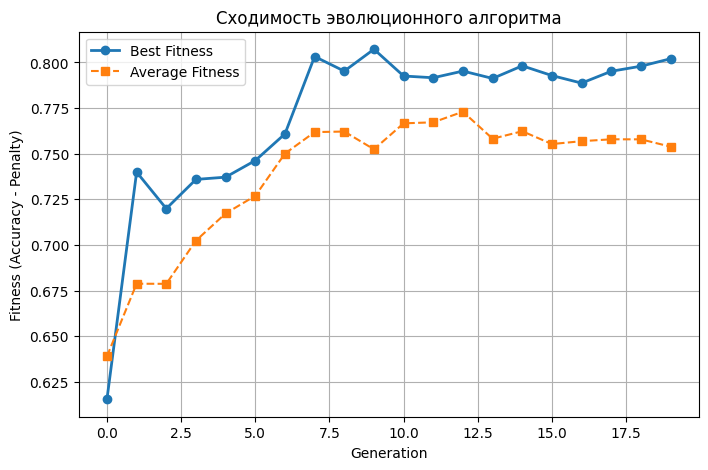

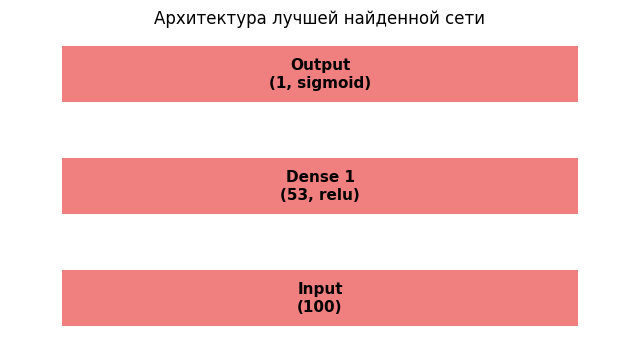

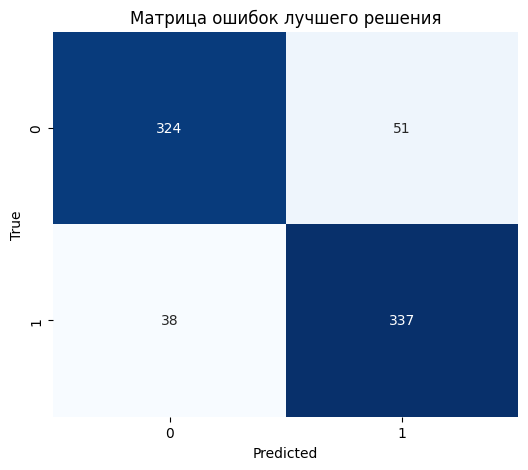

In [9]:
CONFIG = {
    "pop_size": 15,
    "generations": 20,
    "mutation_rate": 0.3,
    "elitism_count": 2,
    "max_epochs": 15,
    "early_stopping_patience": 3,
    "penalty_weight": 0.05,
    "val_size": 0.15,
    "test_size": 0.15
}

runner = ExperimentRunner(CONFIG)
runner.run()